# Exploring viral families in recent history

- **Summary**: This document explores the historical occurrences and severities of existing viral pathogens to create a scaling factor for Madhav's respiratory exceedance.

- **Data Required:** `epidemics_marani_240816.xlsx`

- **Author**: Ganqi Li (ganqi.li.25@dartmouth.edu)
- **Updated**: Sep 16, 2024

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.integrate import quad
from scipy.stats import genpareto
from scipy.optimize import minimize

## repeated printouts
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

In [ ]:
# Set filepaths
rawdata_dir = Path("../../data/raw").resolve()
cleandata_dir = Path("../../data/clean").resolve()
figdir = Path("../../output/exceedance_figures").resolve()

## 0. Prepare respiratory viral families

In [2]:
## Read epidemic data from Marani et al. 
df = pd.read_excel(rawdata_dir / "epidemics_marani_240816.xlsx")
df = df.sort_values(by='year_start', ascending=True).reset_index(drop=True)


In [3]:
## Explore unique viral diseases
viral_diseases = df[df['type'].str.contains("viral", case=False, na=False)]['disease'].unique()

## Display results
print(f"{len(viral_diseases)} symptoms that may be caused by viral pathogens:")
print()
print(viral_diseases)


22 symptoms that may be caused by viral pathogens:

['smallpox' 'influenza' 'measles' 'yellow fever' 'rubella'
 'venereal disease' 'meningitis' 'dengue' 'polio' 'pneumonia'
 'murray valley encephalitis' 'encephalitis' 'mumps' 'west nile'
 'kyasanur forest disease' 'hemorrhagic fever' 'ebola' 'rift valley fever'
 'hiv/aids' 'sars' 'mers' 'covid-19']


In [4]:
## Map viral symptoms to families
family_mapping = {
    'smallpox': 'poxviridae',
    'influenza': 'orthomyxoviridae',
    'measles': 'paramyxoviridae',
    'yellow fever': 'flaviviridae',
    'rubella': 'matonaviridae',
    'venereal disease': 'misc',
    'meningitis': 'misc',
    'dengue': 'flaviviridae',
    'polio': 'picornaviridae',
    'pneumonia': 'misc',
    'murray valley encephalitis': 'flaviviridae',
    'encephalitis': 'misc',
    'mumps': 'paramyxoviridae',
    'west nile': 'flaviviridae',
    'kyasanur forest disease': 'flaviviridae',
    'hemorrhagic fever': 'misc',
    'ebola': 'filoviridae',
    'rift valley fever': 'bunyaviridae',
    'hiv/aids': 'retroviridae',
    'sars': 'coronaviridae',
    'mers': 'coronaviridae',
    'covid-19': 'coronaviridae',
}

## Create family column 
df['family'] = df['disease'].map(family_mapping)


In [5]:
## Save dataframe to excel file
df.to_excel(rawdata_dir / "epidemics_marani_240914_family.xlsx", index=False)


In [6]:
## Create dictionary to aggregate symptoms by family
family_symptoms = {}
for symptom, family in family_mapping.items():
    if family not in family_symptoms:
        family_symptoms[family] = []
    family_symptoms[family].append(symptom)

## Display epidemic-inducing symptoms within each family since 1500
family_symptoms  


{'poxviridae': ['smallpox'],
 'orthomyxoviridae': ['influenza'],
 'paramyxoviridae': ['measles', 'mumps'],
 'flaviviridae': ['yellow fever',
  'dengue',
  'murray valley encephalitis',
  'west nile',
  'kyasanur forest disease'],
 'matonaviridae': ['rubella'],
 'misc': ['venereal disease',
  'meningitis',
  'pneumonia',
  'encephalitis',
  'hemorrhagic fever'],
 'picornaviridae': ['polio'],
 'filoviridae': ['ebola'],
 'bunyaviridae': ['rift valley fever'],
 'retroviridae': ['hiv/aids'],
 'coronaviridae': ['sars', 'mers', 'covid-19']}

## 1. Explore viral families in the modern period

In [7]:
## Subset data to specific modern period
yrmin = 1900
df = df[(df["year_start"] >= yrmin)].reset_index(drop=True)


In [8]:
## Subset to viral epidemics
df_viral = df[df['type'].str.contains('viral', case=False, na=False)
             ].reset_index(drop=True)

## Subset to viral epidemics with known intensities
df_viral_known = df_viral[df_viral["severity_smu"] > 0].reset_index(drop=True)


In [9]:
## Group occurrence by viral families
df_viral_unique = df_viral_known.groupby(['family']
                                        ).size().reset_index(name='count')

## Sort by number of occurrences in descending order
df_viral_unique = df_viral_unique.sort_values(by='count', 
                                              ascending=False).reset_index(drop=True)

## Display results
df_viral_unique 

,family,count
0,misc,14
1,orthomyxoviridae,8
2,poxviridae,7
3,picornaviridae,5
4,flaviviridae,4
5,paramyxoviridae,4
6,coronaviridae,3
7,filoviridae,3
8,retroviridae,1


## 2. Examine each viral family in detail

In [10]:
## Only keep key columns in viral dataframe
df_viral_known = df_viral_known.loc[:, ['location', 'year_start', 'year_end', 
                                        'duration', 'severity_smu', 'disease', 
                                        'family']]


In [11]:
## Display orthomyxoviridae family
df_orthomyxoviridae = df_viral_known[df_viral_known['family'] == "orthomyxoviridae"].reset_index(drop=True)
orthomyxoviridae_severity = df_orthomyxoviridae['severity_smu'].mean()

print("1. Orthomyxoviridae family")
df_orthomyxoviridae
print()


1. Orthomyxoviridae family


,location,year_start,year_end,duration,severity_smu,disease,family
0,"usa, yukon",1900,1900,1,0.000612,influenza,orthomyxoviridae
1,pandemic spanish flu,1918,1920,3,170.821545,influenza,orthomyxoviridae
2,"salomon islands, ontong java",1926,1926,1,0.000163,influenza,orthomyxoviridae
3,pandemic of asian flu,1957,1958,2,6.960623,influenza,orthomyxoviridae
4,hong kong flu,1968,1969,2,2.815633,influenza,orthomyxoviridae
5,papua new guinea,1969,1970,2,0.008274,influenza,orthomyxoviridae
6,swine flu,2009,2009,1,0.413953,influenza,orthomyxoviridae
7,indian swine flu outbreak,2015,2015,1,0.002710,influenza,orthomyxoviridae


<Figure size 1800x500 with 0 Axes>

Text(0.0006123698714023271, 1.2, '1900')

Text(170.8215448673464, 3.2, '1918')

Text(0.0001633286039528822, 1.2, '1926')

Text(6.960623059291283, 2.2, '1957')

...

Text(0.002710101646427402, 1.2, '2015')

(0.0001, 1000.0)

(0.0, 5.0)

Text(0.5, 0, 'Epidemic severity (SMU = deaths per 10,000 people) (log scale)')

Text(0, 0.5, 'Duration (years)')

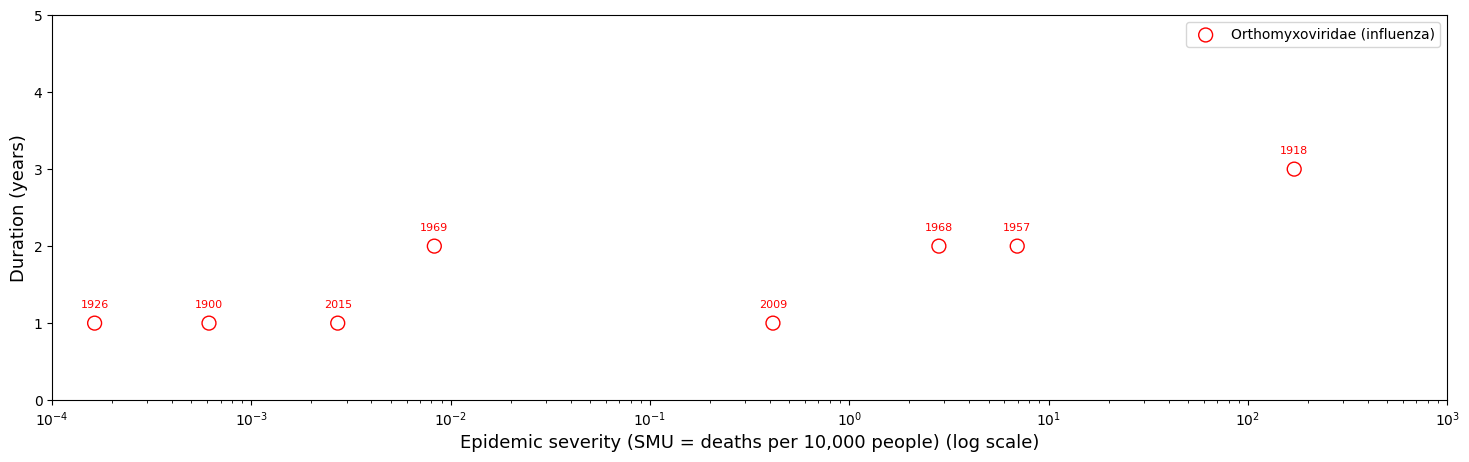

In [40]:
## Set figure size
plt.figure(figsize=(18, 5))

## Plot duration vs severity for epidemics  
plt.scatter(df_orthomyxoviridae['severity_smu'], 
            df_orthomyxoviridae['duration'], 
            edgecolor='red', facecolors='none', label='Orthomyxoviridae (influenza)', s=100)

for i in range(len(df_orthomyxoviridae)):
    plt.text(df_orthomyxoviridae['severity_smu'].iloc[i], 
             df_orthomyxoviridae['duration'].iloc[i] + 0.2,  ## Offset to above circle
             str(df_orthomyxoviridae['year_start'].iloc[i]), 
             ha='center', 
             fontsize = 8, color = 'red')

## Set x-axis scale and limits
plt.xscale('log')
plt.xlim(1e-4, 1e3)

## Set y-axis limits
plt.ylim(0,5)

## Add title and axes labels
# plt.title('Censored  Durations of Threshold-Exceeding Respiratory Epidemics', fontsize = 12)
plt.xlabel('Epidemic severity (SMU = deaths per 10,000 people) (log scale)', fontsize=13)
plt.ylabel('Duration (years)', fontsize = 13)


## Display legend
plt.legend()

plt.show()


In [13]:
## Display poxviridae family
df_poxviridae = df_viral_known[df_viral_known['family'] == "poxviridae"].reset_index(drop=True)
poxviridae_severity = df_poxviridae['severity_smu'].mean()

print("2. Poxviridae family")
df_poxviridae
print()


2. Poxviridae family


,location,year_start,year_end,duration,severity_smu,disease,family
0,"russia, france, england, wales, italy, hungary...",1900,1950,51,9.246785,smallpox,poxviridae
1,japan,1908,1908,1,0.033383,smallpox,poxviridae
2,chad,1922,1923,2,0.041228,smallpox,poxviridae
3,nigeria,1930,1935,6,0.047566,smallpox,poxviridae
4,ghana,1945,1945,1,0.002475,smallpox,poxviridae
5,zambia,1955,1956,2,0.001801,smallpox,poxviridae
6,smallpox epidemic of india,1974,1974,1,0.064938,smallpox,poxviridae


<Figure size 1800x500 with 0 Axes>

Text(9.246785058175139, 53, '1900')

Text(0.03338321630021872, 3, '1908')

Text(0.04122755031049499, 4, '1922')

Text(0.04756619628983669, 8, '1930')

...

Text(0.064938405921983, 3, '1974')

(0.0001, 1000.0)

(0.0, 60.0)

Text(0.5, 0, 'Epidemic severity (SMU = deaths per 10,000 people) (log scale)')

Text(0, 0.5, 'Duration (years)')

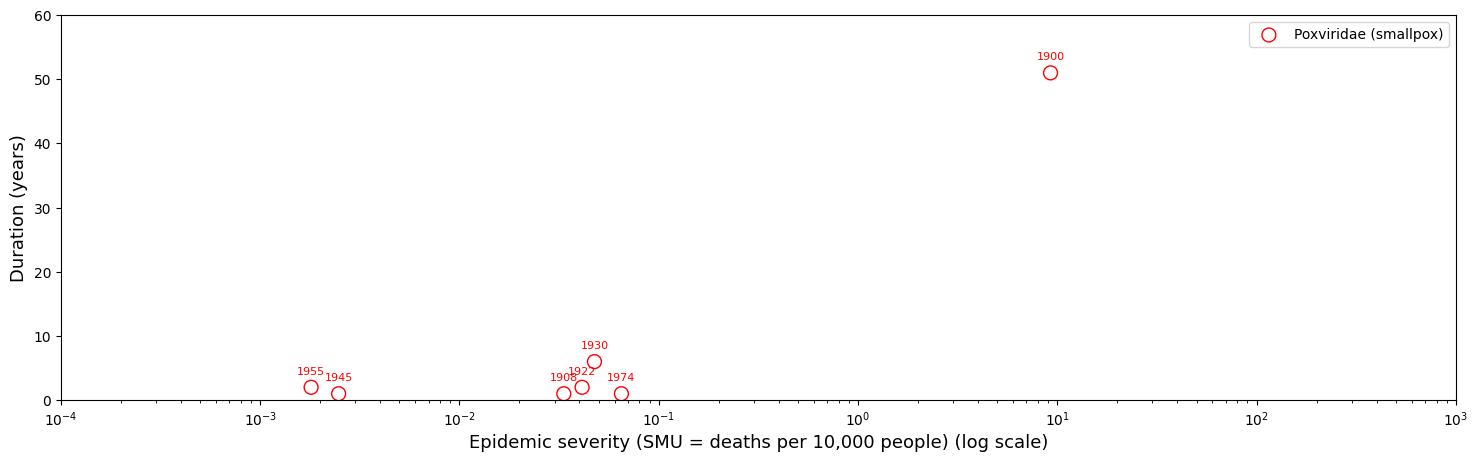

In [39]:
## Set figure size
plt.figure(figsize=(18, 5))

## Plot duration vs severity for epidemics  
plt.scatter(df_poxviridae['severity_smu'], 
            df_poxviridae['duration'], 
            edgecolor='red', facecolors='none', label='Poxviridae (smallpox)', s=100)

for i in range(len(df_poxviridae)):
    plt.text(df_poxviridae['severity_smu'].iloc[i], 
             df_poxviridae['duration'].iloc[i] + 2,  ## Offset to above circle
             str(df_poxviridae['year_start'].iloc[i]), 
             ha='center', 
             fontsize = 8, color = 'red')

## Set x-axis scale and limits
plt.xscale('log')
plt.xlim(1e-4, 1e3)

## Set y-axis limits
plt.ylim(0,60)

## Add title and axes labels
# plt.title('Censored  Durations of Threshold-Exceeding Respiratory Epidemics', fontsize = 12)
plt.xlabel('Epidemic severity (SMU = deaths per 10,000 people) (log scale)', fontsize=13)
plt.ylabel('Duration (years)', fontsize = 13)


## Display legend
plt.legend()

plt.show()


In [17]:
## Display picornaviridae family
df_picornaviridae = df_viral_known[df_viral_known['family'] == "picornaviridae"].reset_index(drop=True)
picornaviridae_severity = df_picornaviridae['severity_smu'].mean()

print("3. Picornaviridae family")
df_picornaviridae
print()


3. Picornaviridae family


,location,year_start,year_end,duration,severity_smu,disease,family
0,american polio epidemic,1916,1916,1,0.038060,polio,picornaviridae
1,united states,1931,1931,1,0.018839,polio,picornaviridae
2,"usa, los angeles",1934,1934,1,0.000457,polio,picornaviridae
3,usa,1942,1949,8,0.033775,polio,picornaviridae
4,israel,1950,1952,3,0.000394,polio,picornaviridae


<Figure size 1800x500 with 0 Axes>

Text(0.03806046067294157, 1.4, '1916')

Text(0.01883904391852113, 1.4, '1931')

Text(0.0004574565416285453, 1.4, '1934')

Text(0.03377534632707926, 8.4, '1942')

Text(0.0003942547591097154, 3.4, '1950')

(0.0001, 1000.0)

(0.0, 10.0)

Text(0.5, 0, 'Epidemic severity (SMU = deaths per 10,000 people) (log scale)')

Text(0, 0.5, 'Duration (years)')

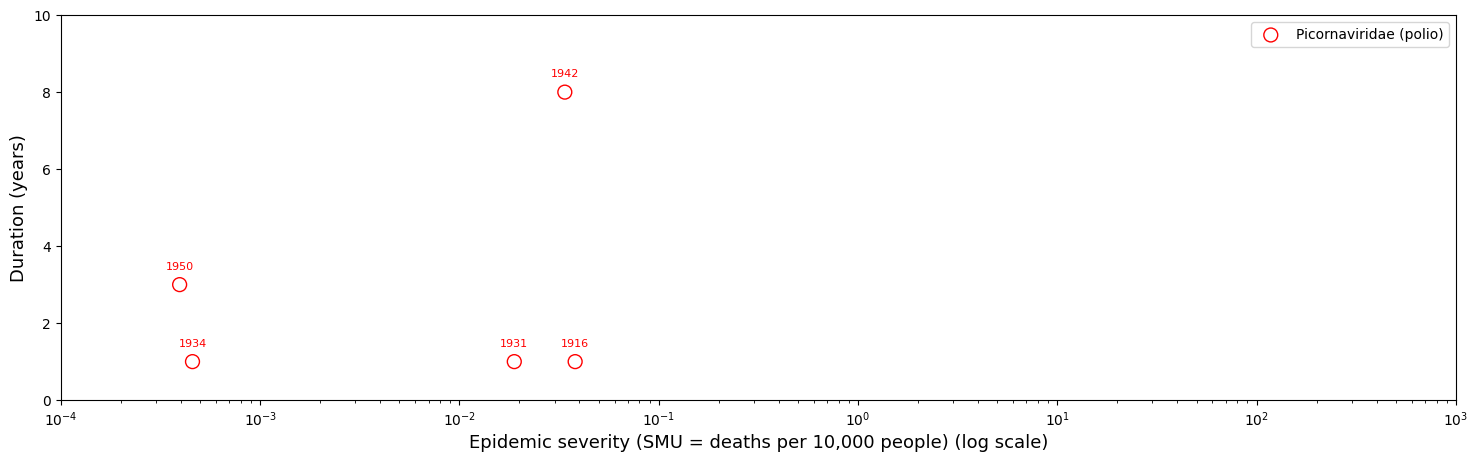

In [42]:
## Set figure size
plt.figure(figsize=(18, 5))

## Plot duration vs severity for epidemics  
plt.scatter(df_picornaviridae['severity_smu'], 
            df_picornaviridae['duration'], 
            edgecolor='red', facecolors='none', label='Picornaviridae (polio)', s=100)

for i in range(len(df_picornaviridae)):
    plt.text(df_picornaviridae['severity_smu'].iloc[i], 
             df_picornaviridae['duration'].iloc[i] + 0.4,  ## Offset to above circle
             str(df_picornaviridae['year_start'].iloc[i]), 
             ha='center', 
             fontsize = 8, color = 'red')

## Set x-axis scale and limits
plt.xscale('log')
plt.xlim(1e-4, 1e3)

## Set y-axis limits
plt.ylim(0,10)

## Add title and axes labels
# plt.title('Censored  Durations of Threshold-Exceeding Respiratory Epidemics', fontsize = 12)
plt.xlabel('Epidemic severity (SMU = deaths per 10,000 people) (log scale)', fontsize=13)
plt.ylabel('Duration (years)', fontsize = 13)


## Display legend
plt.legend()

plt.show()



In [20]:
## Display flaviviridae family
df_flaviviridae = df_viral_known[df_viral_known['family'] == "flaviviridae"].reset_index(drop=True)
flaviviridae_severity = df_flaviviridae['severity_smu'].mean()

print("4. Flaviviridae family")
df_flaviviridae
print()


4. Flaviviridae family


,location,year_start,year_end,duration,severity_smu,disease,family
0,sudan,1939,1939,1,0.006549,yellow fever,flaviviridae
1,japan,1942,1945,4,0.004244,dengue,flaviviridae
2,vietnam and singapore,1973,1973,1,0.035644,dengue,flaviviridae
3,nigeria,1986,1990,5,0.008064,yellow fever,flaviviridae


<Figure size 1800x500 with 0 Axes>

Text(0.006548550223742134, 1.4, '1939')

Text(0.004243606427537329, 4.4, '1942')

Text(0.03564353948057249, 1.4, '1973')

Text(0.008063592717608144, 5.4, '1986')

(0.0001, 1000.0)

(0.0, 10.0)

Text(0.5, 0, 'Epidemic severity (SMU = deaths per 10,000 people) (log scale)')

Text(0, 0.5, 'Duration (years)')

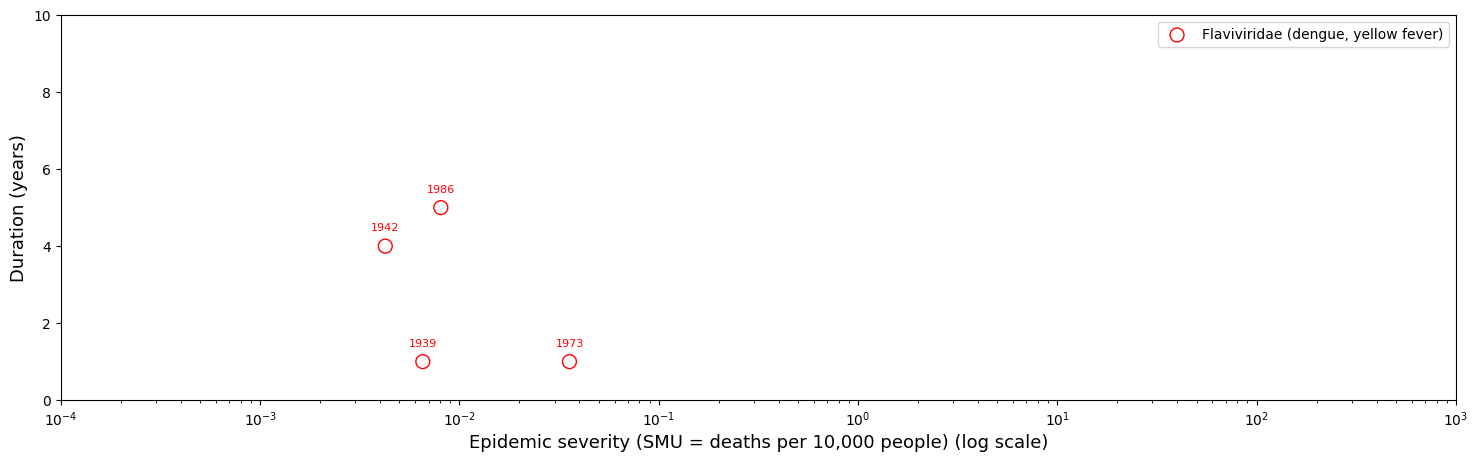

In [44]:
## Set figure size
plt.figure(figsize=(18, 5))

## Plot duration vs severity for epidemics  
plt.scatter(df_flaviviridae['severity_smu'], 
            df_flaviviridae['duration'], 
            edgecolor='red', facecolors='none', label='Flaviviridae (dengue, yellow fever)', s=100)

for i in range(len(df_flaviviridae)):
    plt.text(df_flaviviridae['severity_smu'].iloc[i], 
             df_flaviviridae['duration'].iloc[i] + 0.4,  ## Offset to above circle
             str(df_flaviviridae['year_start'].iloc[i]), 
             ha='center', 
             fontsize = 8, color = 'red')

## Set x-axis scale and limits
plt.xscale('log')
plt.xlim(1e-4, 1e3)

## Set y-axis limits
plt.ylim(0,10)

## Add title and axes labels
# plt.title('Censored  Durations of Threshold-Exceeding Respiratory Epidemics', fontsize = 12)
plt.xlabel('Epidemic severity (SMU = deaths per 10,000 people) (log scale)', fontsize=13)
plt.ylabel('Duration (years)', fontsize = 13)


## Display legend
plt.legend()

plt.show()


In [24]:
## Display paramyxoviridae family
df_paramyxoviridae = df_viral_known[df_viral_known['family'] == "paramyxoviridae"].reset_index(drop=True)
paramyxoviridae_severity = df_paramyxoviridae['severity_smu'].mean()

print("5. Paramyxoviridae family")
df_paramyxoviridae
print()


5. Paramyxoviridae family


,location,year_start,year_end,duration,severity_smu,disease,family
0,fiji islands,1903,1903,1,0.287056,measles,paramyxoviridae
1,american army,1917,1917,1,0.016133,measles,paramyxoviridae
2,britain,1950,1951,2,0.197127,measles,paramyxoviridae
3,measles in d.r. congo,2011,2018,8,0.006391,measles,paramyxoviridae


<Figure size 1800x500 with 0 Axes>

Text(0.2870555871183805, 1.4, '1903')

Text(0.01613271849750615, 1.4, '1917')

Text(0.1971273795548577, 2.4, '1950')

Text(0.006390961532944554, 8.4, '2011')

(0.0001, 1000.0)

(0.0, 10.0)

Text(0.5, 0, 'Epidemic severity (SMU = deaths per 10,000 people) (log scale)')

Text(0, 0.5, 'Duration (years)')

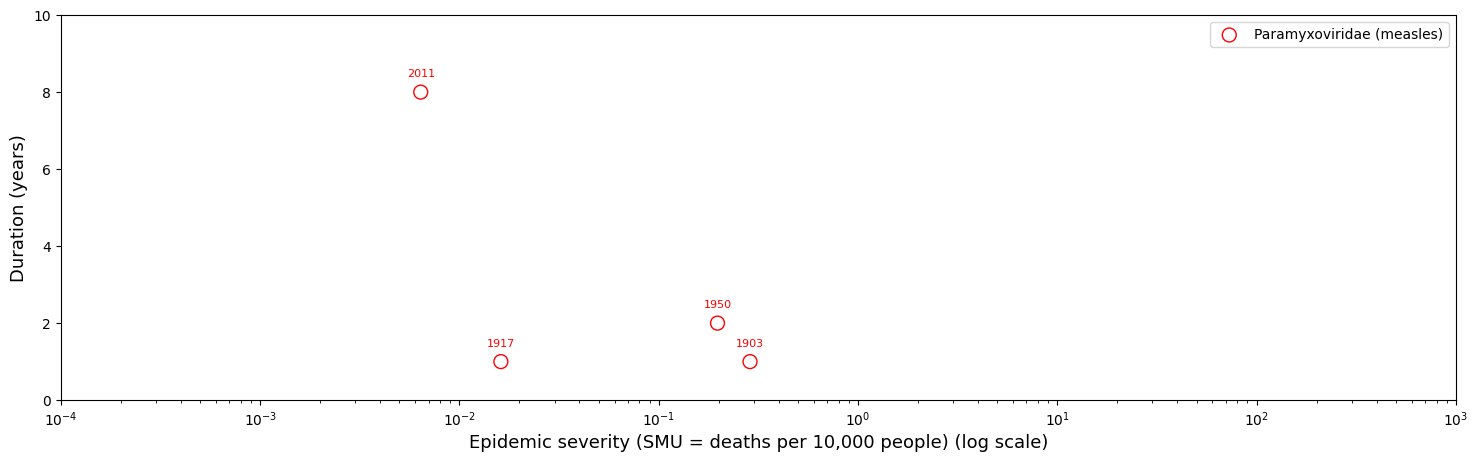

In [45]:
## Set figure size
plt.figure(figsize=(18, 5))

## Plot duration vs severity for epidemics  
plt.scatter(df_paramyxoviridae['severity_smu'], 
            df_paramyxoviridae['duration'], 
            edgecolor='red', facecolors='none', label='Paramyxoviridae (measles)', s=100)

for i in range(len(df_paramyxoviridae)):
    plt.text(df_paramyxoviridae['severity_smu'].iloc[i], 
             df_paramyxoviridae['duration'].iloc[i] + 0.4,  ## Offset to above circle
             str(df_paramyxoviridae['year_start'].iloc[i]), 
             ha='center', 
             fontsize = 8, color = 'red')

## Set x-axis scale and limits
plt.xscale('log')
plt.xlim(1e-4, 1e3)

## Set y-axis limits
plt.ylim(0,10)

## Add title and axes labels
# plt.title('Censored  Durations of Threshold-Exceeding Respiratory Epidemics', fontsize = 12)
plt.xlabel('Epidemic severity (SMU = deaths per 10,000 people) (log scale)', fontsize=13)
plt.ylabel('Duration (years)', fontsize = 13)

## Display legend
plt.legend()

plt.show()


In [27]:
## Display coronaviridae family
df_coronaviridae = df_viral_known[df_viral_known['family'] == "coronaviridae"].reset_index(drop=True)
coronaviridae_severity = df_coronaviridae['severity_smu'].mean()

print("6. Coronaviridae family")
df_coronaviridae
print()


6. Coronaviridae family


,location,year_start,year_end,duration,severity_smu,disease,family
0,global sars,2003,2003,1,0.001166,sars,coronaviridae
1,global mers,2012,2017,6,0.000925,mers,coronaviridae
2,global covid-19,2019,2024,6,9.173127,covid-19,coronaviridae


<Figure size 1800x500 with 0 Axes>

Text(0.00116592761933782, 1.4, '2003')

Text(0.0009248048142288316, 6.4, '2012')

Text(9.17312661498708, 6.4, '2019')

(0.0001, 1000.0)

(0.0, 10.0)

Text(0.5, 0, 'Epidemic severity (SMU = deaths per 10,000 people) (log scale)')

Text(0, 0.5, 'Duration (years)')

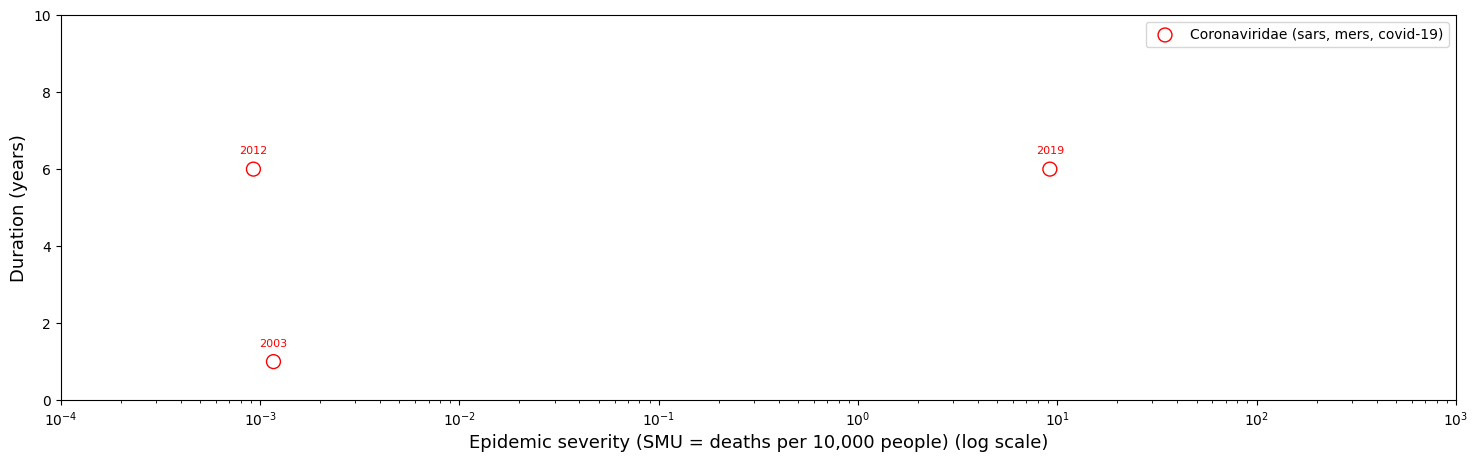

In [46]:
## Set figure size
plt.figure(figsize=(18, 5))

## Plot duration vs severity for epidemics  
plt.scatter(df_coronaviridae['severity_smu'], 
            df_coronaviridae['duration'], 
            edgecolor='red', facecolors='none', label='Coronaviridae (sars, mers, covid-19)', s=100)

for i in range(len(df_coronaviridae)):
    plt.text(df_coronaviridae['severity_smu'].iloc[i], 
             df_coronaviridae['duration'].iloc[i] + 0.4,  ## Offset to above circle
             str(df_coronaviridae['year_start'].iloc[i]), 
             ha='center', 
             fontsize = 8, color = 'red')

## Set x-axis scale and limits
plt.xscale('log')
plt.xlim(1e-4, 1e3)

## Set y-axis limits
plt.ylim(0,10)

## Add title and axes labels
# plt.title('Censored  Durations of Threshold-Exceeding Respiratory Epidemics', fontsize = 12)
plt.xlabel('Epidemic severity (SMU = deaths per 10,000 people) (log scale)', fontsize=13)
plt.ylabel('Duration (years)', fontsize = 13)

## Display legend
plt.legend()

plt.show()


In [30]:
## Display filoviridae family
df_filoviridae = df_viral_known[df_viral_known['family'] == "filoviridae"].reset_index(drop=True)
filoviridae_severity = df_filoviridae['severity_smu'].mean()

print("7. Filoviridae family")
df_filoviridae
print()


7. Filoviridae family


,location,year_start,year_end,duration,severity_smu,disease,family
0,zaire,1976,1976,1,0.000525,ebola,filoviridae
1,western africa,2013,2016,4,0.015706,ebola,filoviridae
2,kivu ebola epidemic,2018,2020,3,0.002922,ebola,filoviridae


<Figure size 1800x500 with 0 Axes>

Text(0.0005247111479151106, 1.2, '1976')

Text(0.01570608308732915, 4.2, '2013')

Text(0.002922255765235285, 3.2, '2018')

(0.0001, 1000.0)

(0.0, 5.0)

Text(0.5, 0, 'Epidemic severity (SMU = deaths per 10,000 people) (log scale)')

Text(0, 0.5, 'Duration (years)')

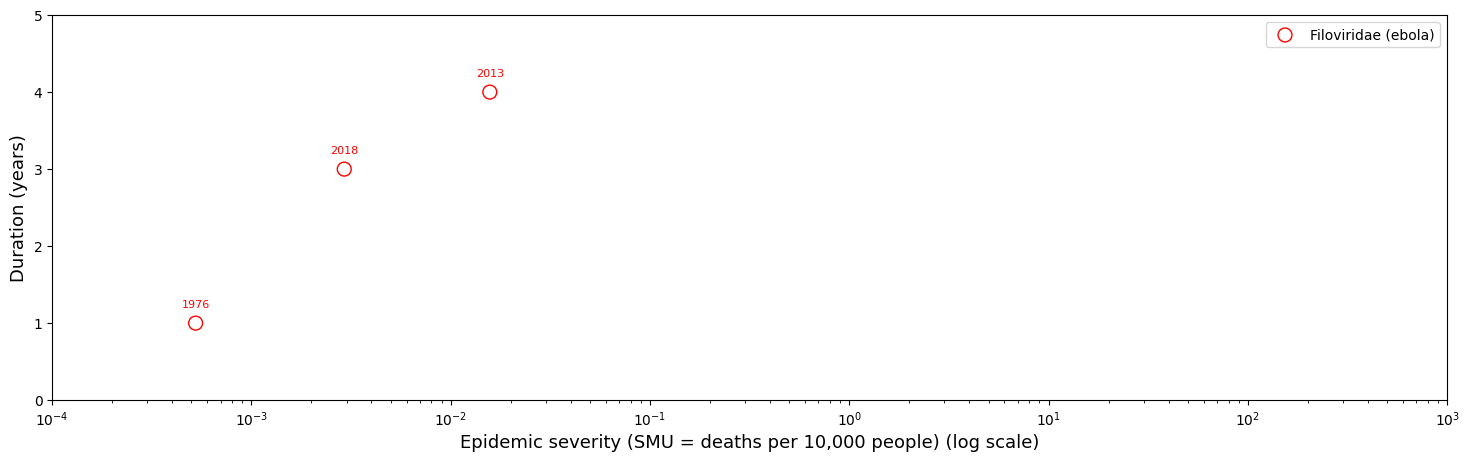

In [47]:
## Set figure size
plt.figure(figsize=(18, 5))

## Plot duration vs severity for epidemics  
plt.scatter(df_filoviridae['severity_smu'], 
            df_filoviridae['duration'], 
            edgecolor='red', facecolors='none', label='Filoviridae (ebola)', s=100)

for i in range(len(df_filoviridae)):
    plt.text(df_filoviridae['severity_smu'].iloc[i], 
             df_filoviridae['duration'].iloc[i] + 0.2,  ## Offset to above circle
             str(df_filoviridae['year_start'].iloc[i]), 
             ha='center', 
             fontsize = 8, color = 'red')

## Set x-axis scale and limits
plt.xscale('log')
plt.xlim(1e-4, 1e3)

## Set y-axis limits
plt.ylim(0,5)

## Add title and axes labels
# plt.title('Censored  Durations of Threshold-Exceeding Respiratory Epidemics', fontsize = 12)
plt.xlabel('Epidemic severity (SMU = deaths per 10,000 people) (log scale)', fontsize=13)
plt.ylabel('Duration (years)', fontsize = 13)


## Display legend
plt.legend()

plt.show()


In [33]:
## Display retroviridae family
df_retroviridae = df_viral_known[df_viral_known['family'] == "retroviridae"].reset_index(drop=True)
retroviridae_severity = df_retroviridae['severity_smu'].mean()

print("8. Retroviridae family")
df_retroviridae
print()


8. Retroviridae family


,location,year_start,year_end,duration,severity_smu,disease,family
0,hiv/aids pandemic,1981,2024,44,93.233484,hiv/aids,retroviridae


<Figure size 1800x500 with 0 Axes>

Text(93.23348362847878, 46, '1981')

(0.0001, 1000.0)

(0.0, 60.0)

Text(0.5, 0, 'Epidemic severity (SMU = deaths per 10,000 people) (log scale)')

Text(0, 0.5, 'Duration (years)')

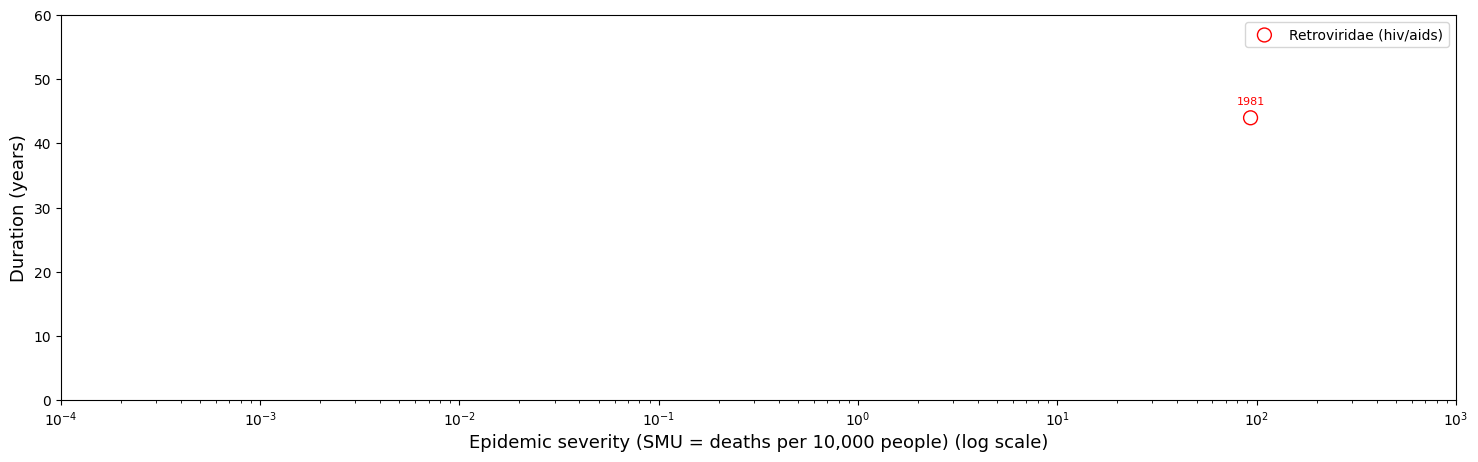

In [50]:
## Set figure size
plt.figure(figsize=(18, 5))

## Plot duration vs severity for epidemics  
plt.scatter(df_retroviridae['severity_smu'], 
            df_retroviridae['duration'], 
            edgecolor='red', facecolors='none', label='Retroviridae (hiv/aids)', s=100)

for i in range(len(df_retroviridae)):
    plt.text(df_retroviridae['severity_smu'].iloc[i], 
             df_retroviridae['duration'].iloc[i] + 2,  ## Offset to above circle
             str(df_retroviridae['year_start'].iloc[i]), 
             ha='center', 
             fontsize = 8, color = 'red')

## Set x-axis scale and limits
plt.xscale('log')
plt.xlim(1e-4, 1e3)

## Set y-axis limits
plt.ylim(0,60)

## Add title and axes labels
# plt.title('Censored  Durations of Threshold-Exceeding Respiratory Epidemics', fontsize = 12)
plt.xlabel('Epidemic severity (SMU = deaths per 10,000 people) (log scale)', fontsize=13)
plt.ylabel('Duration (years)', fontsize = 13)


## Display legend
plt.legend()

plt.show()


## 3. Calculate viral pathogen distribution

In [42]:
## Compile viral family information in 1900-present
viral_dist = {
    'family': ['orthomyxoviridae', 'poxviridae', 'picornaviridae', 'flaviviridae', 'paramyxoviridae', 'coronaviridae', 'filoviridae', 'retroviridae'],
    'symptom': ['influenza', 'smallpox', 'polio', 'dengue, yellow fever', 'measles', 'sars, mers, covid-19', 'ebola', 'hiv/aids'],
    'year_start_first': [1900, 1900, 1916, 1939, 1903, 2003, 1976, 1981],
    'year_start_last': [2015, 1974, 1950, 1986, 2011, 2019, 2018, 1981],
    'arrival_since_1900': [8, 7, 5, 4, 4, 3, 3, 1],
    'eradicated': [0, 1, 0, 0, 0, 0, 0, 0],
    'mean_severity': [orthomyxoviridae_severity, poxviridae_severity, picornaviridae_severity, 
                      flaviviridae_severity, paramyxoviridae_severity, coronaviridae_severity, 
                      filoviridae_severity, retroviridae_severity],
    'emergence_rate': [0, 1/500, 0, 0, 0, 0, 0, 1/500]
}

## Create dataframe
df_viral_dist = pd.DataFrame(viral_dist)

## Display
# df_viral_dist

In [43]:
## Calculate arrival rate within each family
df_viral_dist['arrival_rate'] = (df_viral_dist['arrival_since_1900'] - 1) / (df_viral_dist['year_start_last'] - df_viral_dist['year_start_first'])

## Replace the last row of arrival rate for retroviridae (hiv/aids)
df_viral_dist.at[df_viral_dist.index[-1], 'arrival_rate'] = 0

## Replace the second row of arrival rate for poxviridae (smallpox)
df_viral_dist.at[df_viral_dist.index[1], 'arrival_rate'] = 0


In [44]:
## Calculate average annual losses (AAL, in SMU) within each family 
df_viral_dist['average_annual_loss'] = df_viral_dist['mean_severity'] * (df_viral_dist['arrival_rate'] 
                                                                         + df_viral_dist['emergence_rate'])

## Sort by AAL in descending order
df_viral_dist = df_viral_dist.sort_values(by='average_annual_loss', ascending=False)

## Display
df_viral_dist

,family,symptom,year_start_first,year_start_last,arrival_since_1900,eradicated,mean_severity,emergence_rate,arrival_rate,average_annual_loss
0,orthomyxoviridae,influenza,1900,2015,8,0,22.627939,0.000,0.060870,1.377353
5,coronaviridae,"sars, mers, covid-19",2003,2019,3,0,3.058406,0.000,0.125000,0.382301
7,retroviridae,hiv/aids,1981,1981,1,0,93.233484,0.002,0.000000,0.186467
4,paramyxoviridae,measles,1903,2011,4,0,0.126677,0.000,0.027778,0.003519
1,poxviridae,smallpox,1900,1974,7,1,1.348311,0.002,0.000000,0.002697
2,picornaviridae,polio,1916,1950,5,0,0.018305,0.000,0.117647,0.002154
3,flaviviridae,"dengue, yellow fever",1939,1986,4,0,0.013625,0.000,0.063830,0.000870
6,filoviridae,ebola,1976,2018,3,0,0.006384,0.000,0.047619,0.000304


## 4. Visualize pathogen distribution

In [45]:
## Create labels for graph
df_viral_dist['label'] = df_viral_dist['family'] + ' (' + df_viral_dist['symptom'] + ')'

## Calculate percentage shares
df_viral_dist['share_percentage'] = (df_viral_dist['average_annual_loss'] / 
                                     df_viral_dist['average_annual_loss'].sum()) * 100

## Create legend labels with percentages
df_viral_dist['legend_label'] = df_viral_dist.apply(
    lambda x: f"{x['label']} ({x['share_percentage']:.3f}%)", axis=1
)

## Capitalize first letter of labels
df_viral_dist['legend_label'] = df_viral_dist['legend_label'].str.capitalize()
df_viral_dist

,family,symptom,year_start_first,year_start_last,arrival_since_1900,eradicated,mean_severity,emergence_rate,arrival_rate,average_annual_loss,label,share_percentage,legend_label
0,orthomyxoviridae,influenza,1900,2015,8,0,22.627939,0.000,0.060870,1.377353,orthomyxoviridae (influenza),70.428939,Orthomyxoviridae (influenza) (70.429%)
5,coronaviridae,"sars, mers, covid-19",2003,2019,3,0,3.058406,0.000,0.125000,0.382301,"coronaviridae (sars, mers, covid-19)",19.548393,"Coronaviridae (sars, mers, covid-19) (19.548%)"
7,retroviridae,hiv/aids,1981,1981,1,0,93.233484,0.002,0.000000,0.186467,retroviridae (hiv/aids),9.534718,Retroviridae (hiv/aids) (9.535%)
4,paramyxoviridae,measles,1903,2011,4,0,0.126677,0.000,0.027778,0.003519,paramyxoviridae (measles),0.179929,Paramyxoviridae (measles) (0.180%)
1,poxviridae,smallpox,1900,1974,7,1,1.348311,0.002,0.000000,0.002697,poxviridae (smallpox),0.137888,Poxviridae (smallpox) (0.138%)
2,picornaviridae,polio,1916,1950,5,0,0.018305,0.000,0.117647,0.002154,picornaviridae (polio),0.110119,Picornaviridae (polio) (0.110%)
3,flaviviridae,"dengue, yellow fever",1939,1986,4,0,0.013625,0.000,0.063830,0.000870,"flaviviridae (dengue, yellow fever)",0.044469,"Flaviviridae (dengue, yellow fever) (0.044%)"
6,filoviridae,ebola,1976,2018,3,0,0.006384,0.000,0.047619,0.000304,filoviridae (ebola),0.015545,Filoviridae (ebola) (0.016%)


<Figure size 1000x700 with 0 Axes>

([<matplotlib.patches.Wedge at 0x13d934d50>,
 [Text(0.1297122437830947, -1.0923253790939562, ''),
  Text(0.21495175163087923, 1.0787936524056938, ''),
  Text(-0.7228361787635958, 0.8291609365318914, ''),
  Text(-0.9385781069832166, 0.5736472235545133, ''),
  Text(-0.9442588071084299, 0.5642475566612274, ''),
  Text(-0.9486263689476555, 0.5568734255979421, ''),
  Text(-0.9513196543804159, 0.552259825797175, ''),
  Text(-0.9523592038617543, 0.5504652094545174, '')])

Text(0.5, 1.0, 'Viral Family Distirbution by Annual Average Loss (SMU) using 1900-Present Data')

(-1.0999998250453071,
 1.0999969588428686,
 -1.0999986639321644,
 1.0999953679789356)

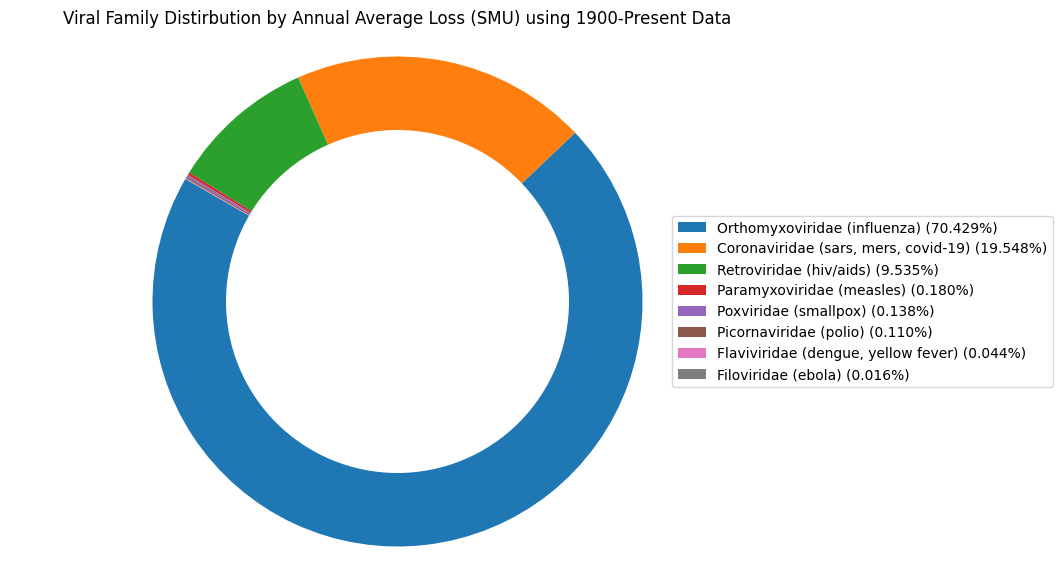

In [46]:
## Plot pie chart
plt.figure(figsize=(10, 7))
plt.pie(df_viral_dist['average_annual_loss'], startangle=150, pctdistance=0.85, labels=None)  ## No labels

## Draw circle at center for a cleaner look
center_circle = plt.Circle((0, 0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(center_circle)

## Add legend with percentages
# plt.legend(df_viral_dist['legend_label'], loc="best", bbox_to_anchor=(0.9, 0))
plt.legend(df_viral_dist['legend_label'], loc="center", bbox_to_anchor=(1.1, 0.5))

## Add title
plt.title('Viral Family Distirbution by Annual Average Loss (SMU) using 1900-Present Data')
plt.axis('equal')  ## Equal aspect ratio ensures pie is circle

## Save graph as jpg file at 400 dpi
plt.savefig(figdir / '09_viral_families.jpg', dpi=400, bbox_inches = 'tight')

## Display 
plt.show()
